In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
stock = pd.read_csv('apple_stock_2016to2026.csv')
stock['date'] = pd.to_datetime(stock['date'])
news_daily = pd.read_csv('news_daily_features.csv')
news_daily['date'] = pd.to_datetime(news_daily['date'])

print('Stock dataset rows    :', len(stock))
print('News daily rows       :', len(news_daily))

Stock dataset rows    : 2585
News daily rows       : 3182


In [3]:
all_dates = pd.date_range(start=news_daily['date'].min(),
                          end=news_daily['date'].max(),
                          freq='D')
print("length of all_dates",len(all_dates))
news_daily = news_daily.set_index('date')
news_daily = news_daily.reindex(all_dates)
print(news_daily.isnull().sum())
print(news_daily.head(5))

news_daily = news_daily.fillna(method='ffill')

news_daily = news_daily.reset_index()
news_daily = news_daily.rename(columns={'index': 'date'})

print("length of news_daily:",len(news_daily))
print(news_daily.isnull().sum())
print('Sample rows including a weekend:')
print(news_daily.head())

length of all_dates 3758
news_count             576
avg_sentiment          576
max_sentiment          576
min_sentiment          576
high_impact_count      576
medium_impact_count    576
negative_count         576
dtype: int64
            news_count  avg_sentiment  max_sentiment  min_sentiment  \
2016-01-01         1.0         0.0000         0.0000         0.0000   
2016-01-02         3.0        -0.0911         0.0000        -0.2732   
2016-01-03         2.0         0.0000         0.0000         0.0000   
2016-01-04         3.0         0.1872         0.4588         0.0000   
2016-01-05         2.0         0.0000         0.0000         0.0000   

            high_impact_count  medium_impact_count  negative_count  
2016-01-01                0.0                  0.0             0.0  
2016-01-02                0.0                  1.0             1.0  
2016-01-03                0.0                  0.0             0.0  
2016-01-04                0.0                  2.0             0.0  
2

C:\Users\hp\AppData\Local\Temp\ipykernel_444\3694049820.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  news_daily = news_daily.fillna(method='ffill')


In [4]:
#Handling Weekend News
trading_dates = np.sort(stock['date'].unique())
news_dates_arr = news_daily['date'].values
idx = np.searchsorted(trading_dates, news_dates_arr)
print(idx[0:15])
idx = np.clip(idx, 0, len(trading_dates) - 1)
news_daily['trading_date'] = trading_dates[idx]
print('HEad News')
print(news_daily[['date', 'trading_date']].head(15))

print('tail News')
print(news_daily[['date', 'trading_date']].tail(10))

[0 0 0 0 1 2 3 4 5 5 5 6 7 8 9]
HEad News
         date trading_date
0  2016-01-01   2016-01-04
1  2016-01-02   2016-01-04
2  2016-01-03   2016-01-04
3  2016-01-04   2016-01-04
4  2016-01-05   2016-01-05
5  2016-01-06   2016-01-06
6  2016-01-07   2016-01-07
7  2016-01-08   2016-01-08
8  2016-01-09   2016-01-11
9  2016-01-10   2016-01-11
10 2016-01-11   2016-01-11
11 2016-01-12   2016-01-12
12 2016-01-13   2016-01-13
13 2016-01-14   2016-01-14
14 2016-01-15   2016-01-15
tail News
           date trading_date
3748 2026-04-06   2026-04-06
3749 2026-04-07   2026-04-07
3750 2026-04-08   2026-04-08
3751 2026-04-09   2026-04-09
3752 2026-04-10   2026-04-10
3753 2026-04-11   2026-04-13
3754 2026-04-12   2026-04-13
3755 2026-04-13   2026-04-13
3756 2026-04-14   2026-04-14
3757 2026-04-15   2026-04-15


In [5]:
#Combine news that maps to the same trading day
news_remapped = news_daily.groupby('trading_date').agg(
    news_count = ('news_count', 'sum'),
    avg_sentiment = ('avg_sentiment', 'sum'),
    max_sentiment = ('max_sentiment', 'max'),
    min_sentiment = ('min_sentiment', 'min'),
    high_impact_count = ('high_impact_count', 'sum'),
    medium_impact_count = ('medium_impact_count', 'sum'),
    negative_count = ('negative_count', 'sum')
).reset_index()
news_remapped = news_remapped.rename(columns={'trading_date': 'date'})
print(news_remapped.head(10))
print('Rows before combining:', len(news_daily))
print('Rows after  combining:', len(news_remapped))
print('Length of stock data set', len(stock))

        date  news_count  avg_sentiment  max_sentiment  min_sentiment  \
0 2016-01-04         9.0         0.0961         0.4588        -0.2732   
1 2016-01-05         2.0         0.0000         0.0000         0.0000   
2 2016-01-06         1.0         0.0000         0.0000         0.0000   
3 2016-01-07        11.0         0.0540         0.3612        -0.1280   
4 2016-01-08         4.0         0.0549         0.7717        -0.2960   
5 2016-01-11         5.0         0.8663         0.6369         0.0000   
6 2016-01-12         5.0         0.0356         0.1779         0.0000   
7 2016-01-13         5.0         0.0848         0.5859        -0.3400   
8 2016-01-14         2.0         0.2294         0.4588         0.0000   
9 2016-01-15         8.0        -0.0502         0.0000        -0.2732   

   high_impact_count  medium_impact_count  negative_count  
0                0.0                  3.0             1.0  
1                0.0                  0.0             0.0  
2               

In [6]:
# Merge stock and news
merged = pd.merge(stock, news_remapped, on='date', how='left')
print('Stock rows:', len(stock))
print('After merge rows:', len(merged))
print('Missing values after merge:')
print(merged.isnull().sum())
print('rows of merged data:')
merged.head()

Stock rows: 2585
After merge rows: 2585
Missing values after merge:
date                   0
Close                  0
High                   0
Low                    0
Open                   0
Volume                 0
news_count             0
avg_sentiment          0
max_sentiment          0
min_sentiment          0
high_impact_count      0
medium_impact_count    0
negative_count         0
dtype: int64
rows of merged data:


,date,Close,High,Low,Open,Volume,news_count,avg_sentiment,max_sentiment,min_sentiment,high_impact_count,medium_impact_count,negative_count
0,2016-01-04,23.709103,23.713605,22.955183,23.092464,270597600,9.0,0.0961,0.4588,-0.2732,0.0,3.0,1.0
1,2016-01-05,23.114971,23.821631,23.047457,23.799126,223164000,2.0,0.0000,0.0000,0.0000,0.0,0.0,0.0
2,2016-01-06,22.662607,23.038443,22.475816,22.631100,273829600,1.0,0.0000,0.0000,0.0000,0.0,0.0,0.0
3,2016-01-07,21.706148,22.534335,21.701648,22.208012,324377600,11.0,0.0540,0.3612,-0.1280,0.0,3.0,1.0
4,2016-01-08,21.820923,22.304782,21.775913,22.178754,283192000,4.0,0.0549,0.7717,-0.2960,1.0,3.0,3.0


In [7]:
#Adding news features
merged['daily_return'] = merged['Close'].pct_change() * 100
merged['price_range'] = merged['High'] - merged['Low']
merged.head(5)

,date,Close,High,Low,Open,Volume,news_count,avg_sentiment,max_sentiment,min_sentiment,high_impact_count,medium_impact_count,negative_count,daily_return,price_range
0,2016-01-04,23.709103,23.713605,22.955183,23.092464,270597600,9.0,0.0961,0.4588,-0.2732,0.0,3.0,1.0,NaN,0.758422
1,2016-01-05,23.114971,23.821631,23.047457,23.799126,223164000,2.0,0.0000,0.0000,0.0000,0.0,0.0,0.0,-2.505921,0.774174
2,2016-01-06,22.662607,23.038443,22.475816,22.631100,273829600,1.0,0.0000,0.0000,0.0000,0.0,0.0,0.0,-1.957017,0.562627
3,2016-01-07,21.706148,22.534335,21.701648,22.208012,324377600,11.0,0.0540,0.3612,-0.1280,0.0,3.0,1.0,-4.220428,0.832687
4,2016-01-08,21.820923,22.304782,21.775913,22.178754,283192000,4.0,0.0549,0.7717,-0.2960,1.0,3.0,3.0,0.528766,0.528869


In [8]:
# Target = tomorrow's Close price
merged['Target'] = merged['Close'].shift(-1)
print(merged.head(3))
print(merged.tail(3))

        date      Close       High        Low       Open     Volume  \
0 2016-01-04  23.709103  23.713605  22.955183  23.092464  270597600   
1 2016-01-05  23.114971  23.821631  23.047457  23.799126  223164000   
2 2016-01-06  22.662607  23.038443  22.475816  22.631100  273829600   

   news_count  avg_sentiment  max_sentiment  min_sentiment  high_impact_count  \
0         9.0         0.0961         0.4588        -0.2732                0.0   
1         2.0         0.0000         0.0000         0.0000                0.0   
2         1.0         0.0000         0.0000         0.0000                0.0   

   medium_impact_count  negative_count  daily_return  price_range     Target  
0                  3.0             1.0           NaN     0.758422  23.114971  
1                  0.0             0.0     -2.505921     0.774174  22.662607  
2                  0.0             0.0     -1.957017     0.562627  21.706148  
           date       Close        High         Low        Open    Volume 

In [9]:
#Droping missing valuse
print(merged.isnull().sum())
merged = merged.dropna()
print(merged.head(1))
print(merged.tail(1))

date                   0
Close                  0
High                   0
Low                    0
Open                   0
Volume                 0
news_count             0
avg_sentiment          0
max_sentiment          0
min_sentiment          0
high_impact_count      0
medium_impact_count    0
negative_count         0
daily_return           1
price_range            0
Target                 1
dtype: int64
        date      Close       High        Low       Open     Volume  \
1 2016-01-05  23.114971  23.821631  23.047457  23.799126  223164000   

   news_count  avg_sentiment  max_sentiment  min_sentiment  high_impact_count  \
1         2.0            0.0            0.0            0.0                0.0   

   medium_impact_count  negative_count  daily_return  price_range     Target  
1                  0.0             0.0     -2.505921     0.774174  22.662607  
           date       Close        High         Low        Open    Volume  \
2583 2026-04-14  258.591736  261.688888  256.9

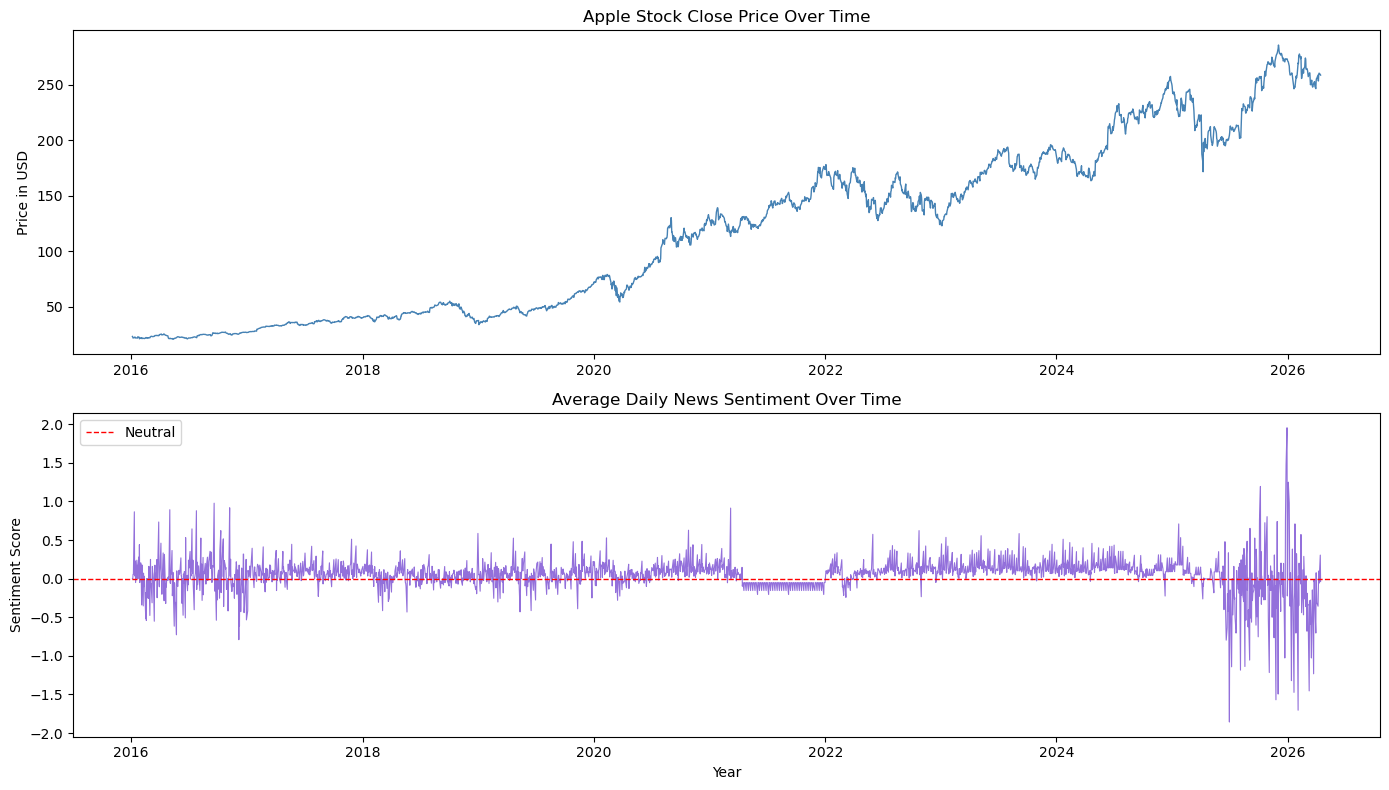

In [10]:
#ploting close price vs average sentiments
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(merged['date'], merged['Close'], color='steelblue', linewidth=1)
axes[0].set_title('Apple Stock Close Price Over Time')
axes[0].set_ylabel('Price in USD')

axes[1].plot(merged['date'], merged['avg_sentiment'], color='mediumpurple', linewidth=0.8)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1, label='Neutral')
axes[1].set_title('Average Daily News Sentiment Over Time')
axes[1].set_ylabel('Sentiment Score')
axes[1].set_xlabel('Year')
axes[1].legend()

plt.tight_layout()

In [11]:
# Final dataset
print(merged.duplicated())
merged.drop_duplicates()
print(merged.isnull().sum())
merged.to_csv('final_dataset.csv', index=False)

1       False
2       False
3       False
4       False
5       False
        ...  
2579    False
2580    False
2581    False
2582    False
2583    False
Length: 2583, dtype: bool
date                   0
Close                  0
High                   0
Low                    0
Open                   0
Volume                 0
news_count             0
avg_sentiment          0
max_sentiment          0
min_sentiment          0
high_impact_count      0
medium_impact_count    0
negative_count         0
daily_return           0
price_range            0
Target                 0
dtype: int64
